<a href="https://colab.research.google.com/github/AkshatkMalik/python-data-science-toolkit/blob/main/Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ASSIGNMENT-14:RANDOM FOREST CLASSIFICATION**

**Task 1: Exploratory Data Analysis**

In this task, we will load the Glass dataset from the Excel workbook (glass.xlsx), explore the data, and identify missing values, inconsistencies, or target class distributions.

In [1]:
import numpy as np
import pandas as pd

#  Load the Excel file and check available sheets
excel_file = pd.ExcelFile('glass.xlsx')
print('Sheet names:', excel_file.sheet_names)

# Load the main data sheet ('glass')
df = pd.read_excel('glass.xlsx', sheet_name='glass')

print('--- Dataset Overview ---')
print(f'Dataset Shape (Rows, Columns): {df.shape}')
print('\nData Types & Non-Null Counts:')
print(df.info())

print('\nMissing Values per Column:\n', df.isnull().sum())

print('\nTarget Variable ("Type") Distribution:')
print(df['Type'].value_counts())

print('\nFirst 3 Rows:')
display(df.head(3))

Sheet names: ['Description', 'glass']
--- Dataset Overview ---
Dataset Shape (Rows, Columns): (214, 10)

Data Types & Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB
None

Missing Values per Column:
 RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

Target Variable ("Type") Distribution:
Type
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1


**Task 2: Data Visualization**

In this task, we will create visualizations such as histograms, box plots, and correlation matrices to assess feature distributions and relationships.

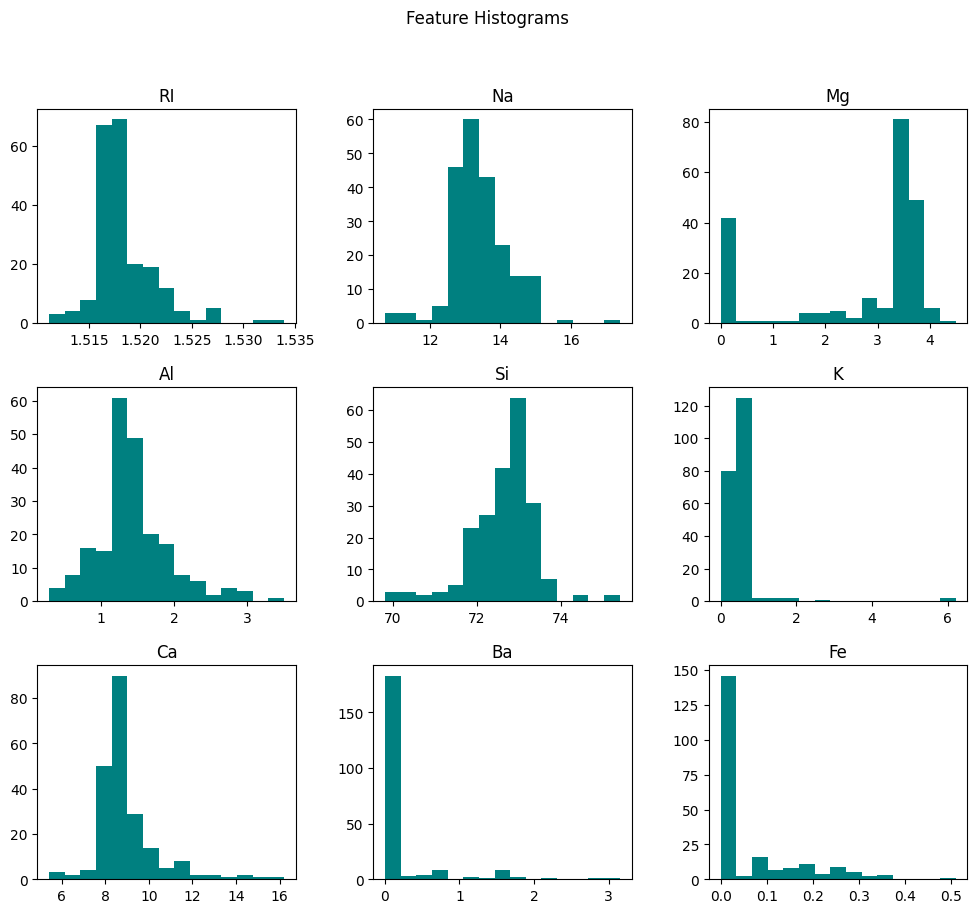

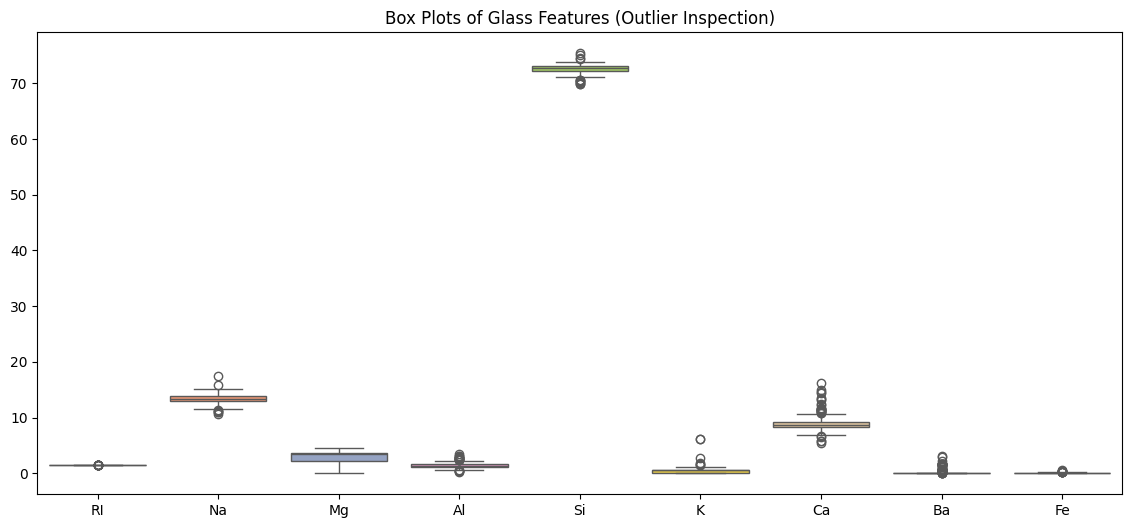

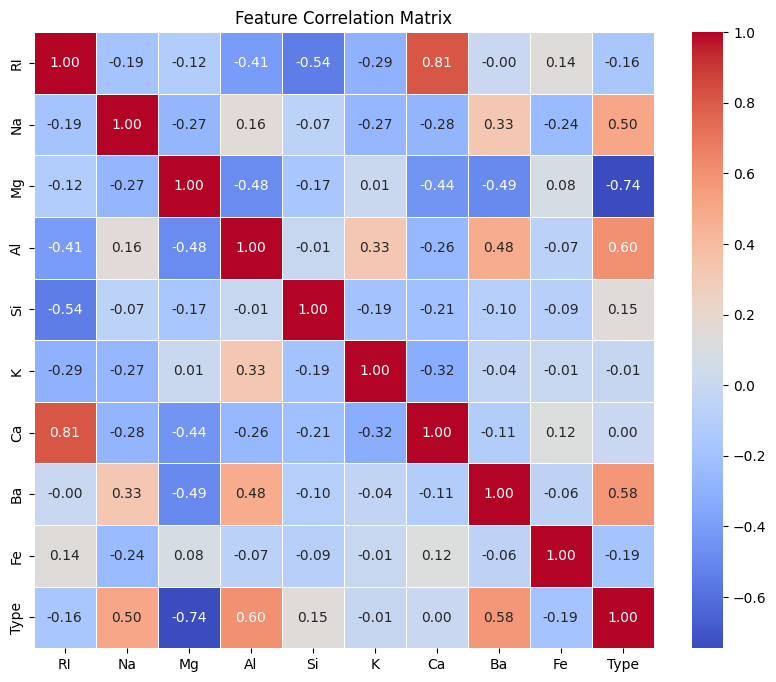

In [2]:

import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe']

#  Histograms of all features
df[num_cols].hist(bins=15, figsize=(12, 10), color='teal', grid=False)
plt.suptitle('Feature Histograms')
plt.show()

#  Box Plots for Outlier Detection
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[num_cols], palette='Set2')
plt.title('Box Plots of Glass Features (Outlier Inspection)')
plt.show()

# correlation Matrix Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5
)
plt.title('Feature Correlation Matrix')
plt.show()

**Task 3: Data Preprocessing**

In this task, we will address missing values and categorical columns (there are none), apply feature scaling (Standardization), and discuss approaches to class imbalance.


In [8]:

from sklearn.preprocessing import StandardScaler

#  Handle missing values: Dataset has 0 nulls. (If nulls existed, median imputation would be used).
print(
    'Total missing values across dataframe:',
    df.isnull().sum().sum(),
    '(No missing values found)',
)

# Categorical encoding check: All features are numeric.
print('All feature data types are numeric; no encoding required.')

#  Separate Features (X) and Target (y)
X = df.drop(columns=['Type'])
y = df['Type']

#  Feature Scaling using Standardization (mean=0, std=1)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print('\nScaled Features Sample:')
display(X_scaled.head(3))

Total missing values across dataframe: 0 (No missing values found)
All feature data types are numeric; no encoding required.

Scaled Features Sample:


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,0.872868,0.284953,1.254639,-0.692442,-1.127082,-0.671705,-0.145766,-0.352877,-0.586451
1,-0.249333,0.591817,0.636168,-0.170460,0.102319,-0.026213,-0.793734,-0.352877,-0.586451
2,-0.721318,0.149933,0.601422,0.190912,0.438787,-0.164533,-0.828949,-0.352877,-0.586451


**Task 4: Random Forest Model Implementation**

In this task, we will divide our data into training and test sets, train our Random Forest Classifier, and evaluate its performance using Accuracy, Precision, Recall, and F1-score.



In [4]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split

# Split data into train (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training Set Rows: {X_train.shape[0]}')
print(f'Testing Set Rows: {X_test.shape[0]}')

# Initialize and Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on Test Data
y_pred = rf_model.predict(X_test)

# Evaluate Performance Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print('--- Random Forest Evaluation Metrics ---')
print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'F1-Score:  {f1:.4f}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred, zero_division=0))

Training Set Rows: 171
Testing Set Rows: 43
--- Random Forest Evaluation Metrics ---
Accuracy:  0.8140
Precision: 0.8262
Recall:    0.8140
F1-Score:  0.8136

Classification Report:
              precision    recall  f1-score   support

           1       0.75      0.86      0.80        14
           2       0.85      0.73      0.79        15
           3       0.67      0.67      0.67         3
           5       1.00      0.67      0.80         3
           6       0.67      1.00      0.80         2
           7       1.00      1.00      1.00         6

    accuracy                           0.81        43
   macro avg       0.82      0.82      0.81        43
weighted avg       0.83      0.81      0.81        43



**Task 5: Bagging and Boosting Methods**

In this task, we will implement other ensemble techniques (Bagging and Boosting) and compare their results.

In [7]:
from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score

# Bagging Classifier
bag_model = BaggingClassifier(n_estimators=100, random_state=42)
bag_model.fit(X_train, y_train)
y_pred_bag = bag_model.predict(X_test)

print(' Bagging Classifier Results ')
print(f'Bagging Accuracy: {accuracy_score(y_test, y_pred_bag):.4f}')
print(
    f'Bagging F1-Score: {f1_score(y_test, y_pred_bag, average="weighted"):.4f}'
)

# Boosting Classifier (Gradient Boosting)
boost_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
boost_model.fit(X_train, y_train)
y_pred_boost = boost_model.predict(X_test)

print('\n Gradient Boosting Results ')
print(f'Boosting Accuracy: {accuracy_score(y_test, y_pred_boost):.4f}')
print(
    f'Boosting F1-Score: {f1_score(y_test, y_pred_boost, average="weighted"):.4f}'
)

 Bagging Classifier Results 
Bagging Accuracy: 0.7907
Bagging F1-Score: 0.7889

 Gradient Boosting Results 
Boosting Accuracy: 0.8140
Boosting F1-Score: 0.8114


**Task 6: Additional Notes & Conceptual Explanations**

1. Explain Bagging and Boosting methods. How are these methods different from each other

Bagging (Bootstrap Aggregating): A method of training a number of base models (mostly decision trees) on randomly selected subsets of the data with replacement. The final model is based on the mean of the outputs for regression problems (average) or a vote for classification problems (majority vote). The goal of bagging is to reduce variance and prevent overfitting.
Boosting: A method of training a number of base models (mostly decision trees) sequentially and sequentially to correct the errors obtained from the previous model. The boosting method reduces the error bias and increases the accuracy of the model.
Difference: Bagging trains base models independently of each other while boosting updates the model sequentially.


---


2. Explain how to handle imbalance in the data.


The solution for imbalance can be achieved by resampling. This can be done by oversampling where the minority class is duplicated to receive a higher number of samples (SMOTE algorithm) or undersampling where the majority class is reduced to receive a lower number of samples. Another approach is to apply algorithm weighting (class_weight='balanced') for those algorithms that provide such an option (e.g., random forest). In addition, it is reasonable to use evaluation metrics that are more accurate for imbalanced data such as F1-score, PR AUC, and a confusion matrix instead of accuracy.